# `pc_to_seq`
Converts a capillary-pressure map into an invasion-sequence map. Voxels are ranked by entry pressure (ascending for drainage, descending for imbibition) and assigned a 1-based sequence index.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import porespy as ps

ps.visualization.set_mpl_style()

The arguments and their defaults are:

In [2]:
import inspect

inspect.signature(ps.filters.pc_to_seq)

<Signature (pc, im, mode='drainage')>

## `pc` and `im`
`pc` is a capillary-pressure map (e.g. from `capillary_transform` or from a drainage simulation). `im` is the void mask. Trapped wetting phase should be encoded as `+inf` in `pc`, and residual non-wetting phase as `-inf`.

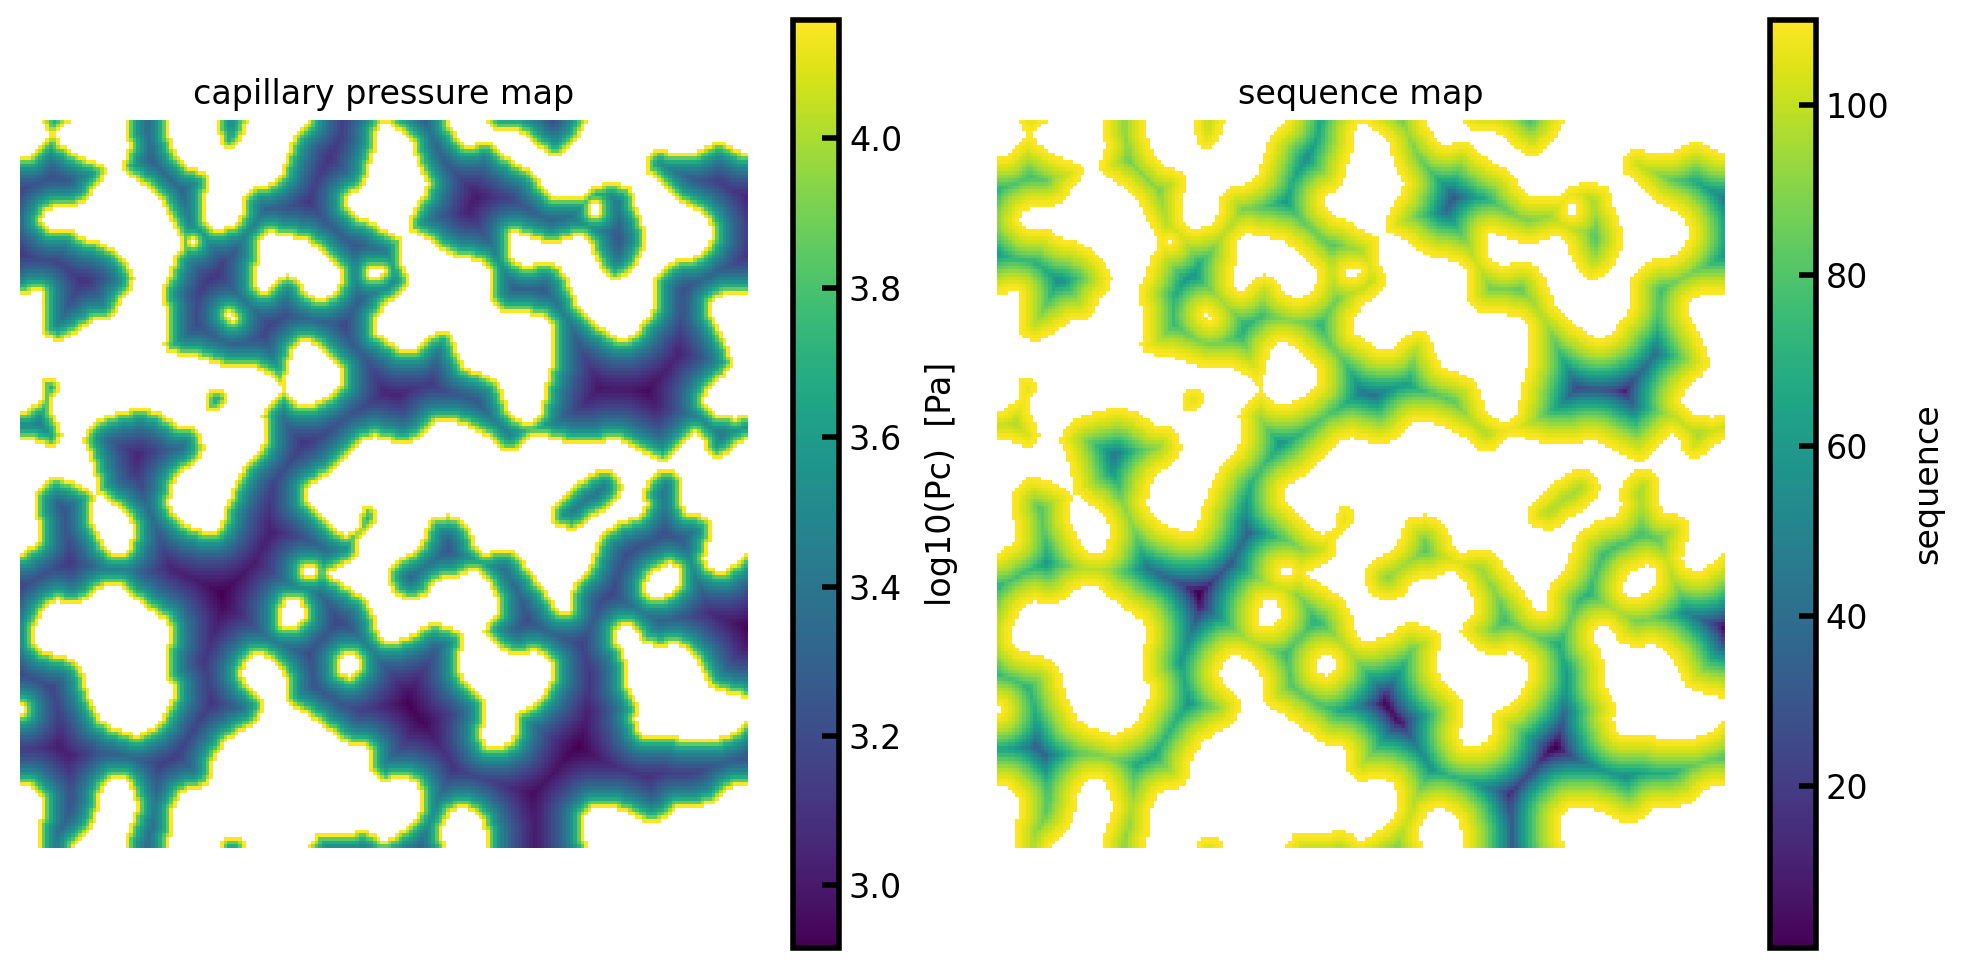

In [3]:
im = ps.generators.blobs(shape=[200, 200], porosity=0.6, seed=0)
pc = ps.filters.capillary_transform(
    im=im, sigma=0.072, theta=180, voxel_size=1e-5)
seq = ps.filters.pc_to_seq(pc=pc, im=im)

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
h0 = ax[0].imshow(np.log10(pc) / im, origin='lower', interpolation='none')
fig.colorbar(h0, ax=ax[0], label='log10(Pc)  [Pa]')
ax[0].set_title('capillary pressure map')
ax[0].axis(False)
h1 = ax[1].imshow(seq / im, origin='lower', interpolation='none')
fig.colorbar(h1, ax=ax[1], label='sequence')
ax[1].set_title('sequence map')
ax[1].axis(False);

## `mode`
Choose `'drainage'` to rank from low to high `pc` (small pores invaded last), or `'imbibition'` for the opposite. Switching `mode` reverses the sequence numbers.

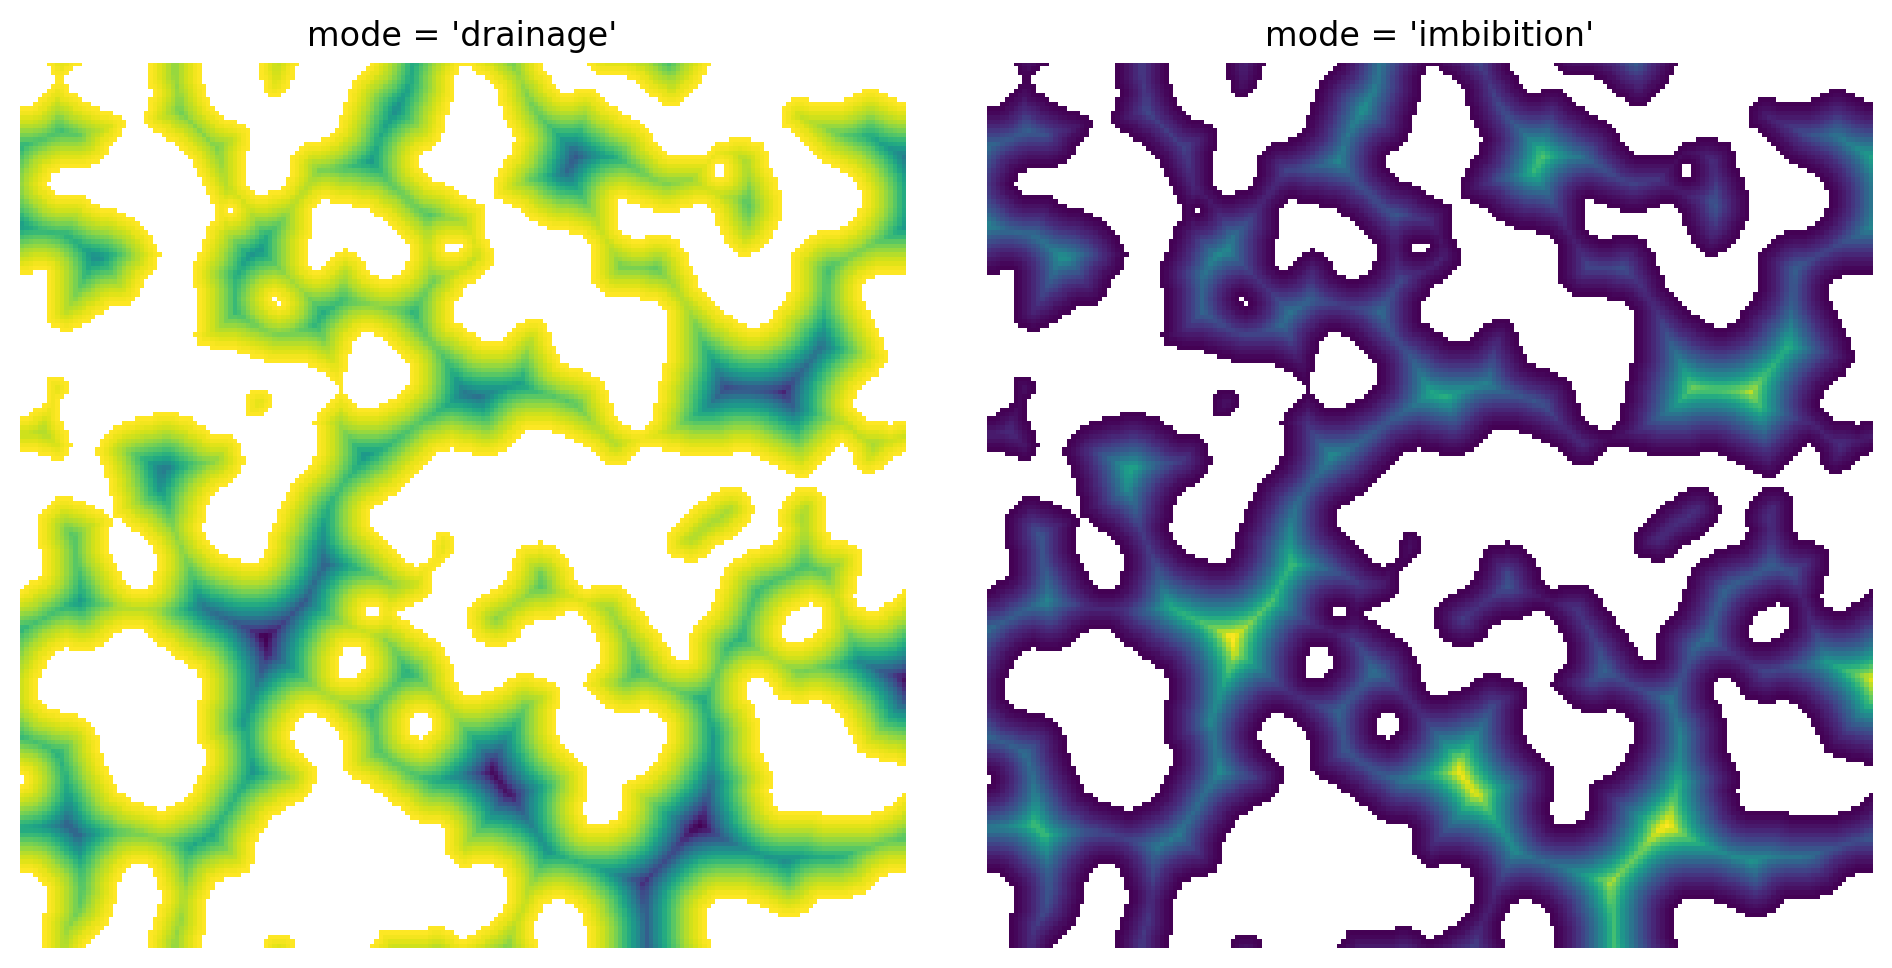

In [4]:
seq_drn = ps.filters.pc_to_seq(pc=pc, im=im, mode='drainage')
seq_imb = ps.filters.pc_to_seq(pc=pc, im=im, mode='imbibition')

fig, ax = plt.subplots(1, 2, figsize=[10, 5])
ax[0].imshow(seq_drn / im, origin='lower', interpolation='none')
ax[0].set_title("mode = 'drainage'")
ax[0].axis(False)
ax[1].imshow(seq_imb / im, origin='lower', interpolation='none')
ax[1].set_title("mode = 'imbibition'")
ax[1].axis(False);

## Trapped and residual phases
Voxels with `pc = +inf` are interpreted as trapped wetting phase (drainage) and appear in the sequence map as `-1`. Voxels with `pc = -inf` are interpreted as residual non-wetting phase already present at the start, and appear as `0`.

unique sequence values: [-1, 0, 1, 2, 3] ...


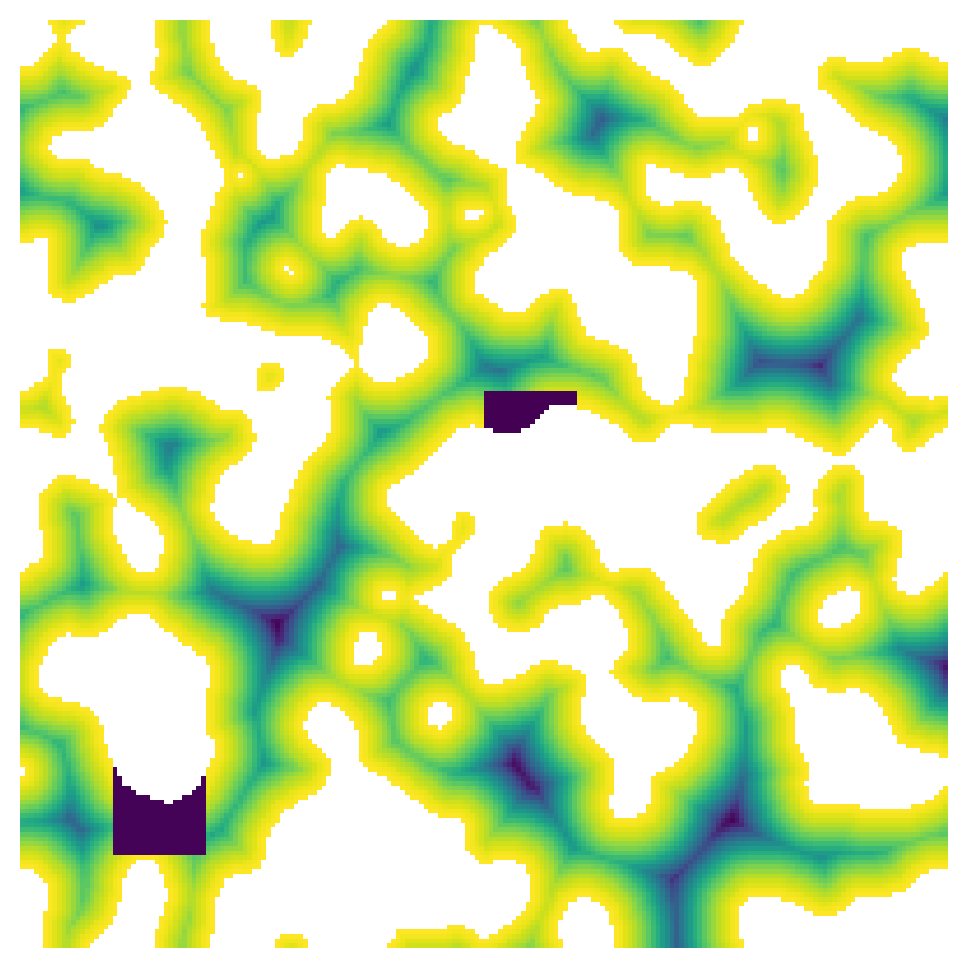

In [5]:
pc_marked = pc.copy()
pc_marked[100:120, 100:120] = np.inf  # patch of trapped wp
pc_marked[20:40, 20:40] = -np.inf  # patch of residual nwp
seq = ps.filters.pc_to_seq(pc=pc_marked, im=im)

fig, ax = plt.subplots(figsize=[5, 5])
ax.imshow(seq / im, origin='lower', interpolation='none')
ax.axis(False)
print('unique sequence values:', np.unique(seq).tolist()[:5], '...')